In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

FOLDER = Path("bildeoppgave2/carsblob/hatchback/")  

patterns = ["*.bmp","*.png","*.jpg","*.jpeg","*.webp","*.tif","*.tiff"]
files = [p for pat in patterns for p in FOLDER.glob(pat)]
assert files, f"No image files found in {FOLDER.resolve()}"

def load_gray_01(path, target_size=None):
    """Load image, convert to grayscale, optional resize, return float32 array in [0,1]."""
    img = Image.open(path).convert("L")
    if target_size is not None:
        # Note: target_size is (H, W)
        img = img.resize((target_size[1], target_size[0]), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

images = []
shapes = []
for f in files:
    arr = load_gray_01(f)
    images.append(arr)
    shapes.append(arr.shape)  # (H, W)






Fant 8 bilder i bildeoppgave2\fjes\2
------------------------------------------------------------

[Bilde 1/8] Prosesserer: Anger.jpg
blobs detektert: 10
    - Blob på (1258, 1814), radius: 82px
    - Blob på (672, 1795), radius: 108px
    - Blob på (850, 2201), radius: 101px
    - Blob på (1420, 2766), radius: 133px
    - Blob på (805, 2574), radius: 109px
    - Blob på (2189, 944), radius: 111px
    - Blob på (2037, 1710), radius: 77px
    - Blob på (1200, 2219), radius: 84px
    - Blob på (1363, 3151), radius: 79px
    - Blob på (2099, 2883), radius: 103px


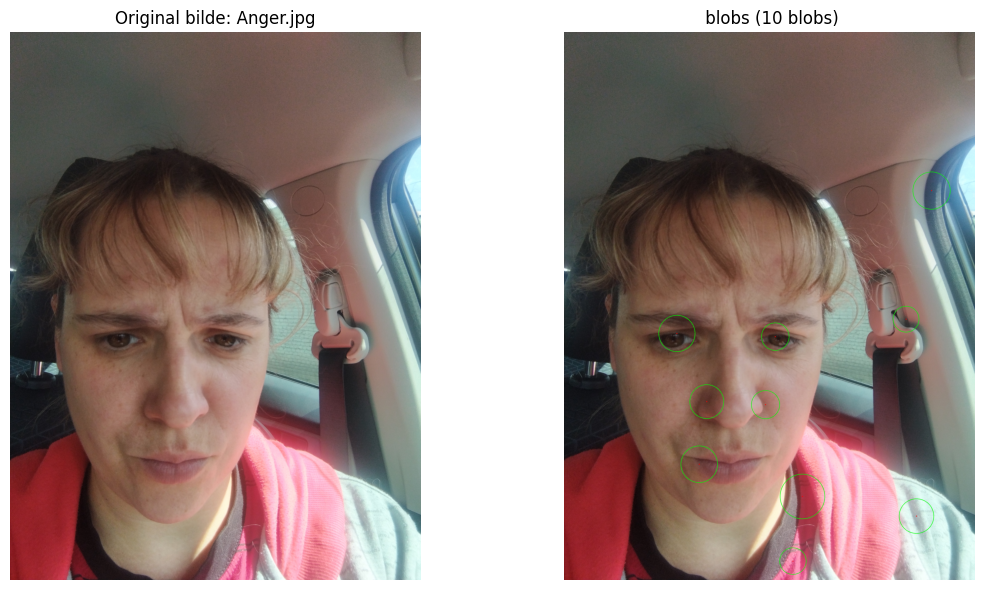


[Bilde 2/8] Prosesserer: Contempt.jpg
blobs detektert: 10
    - Blob på (1884, 1843), radius: 54px
    - Blob på (1250, 1775), radius: 85px
    - Blob på (226, 2642), radius: 82px
    - Blob på (1905, 2288), radius: 100px
    - Blob på (1671, 1850), radius: 72px
    - Blob på (1328, 2367), radius: 77px
    - Blob på (667, 3056), radius: 105px
    - Blob på (2277, 2825), radius: 81px
    - Blob på (1670, 3163), radius: 94px
    - Blob på (1962, 2132), radius: 104px


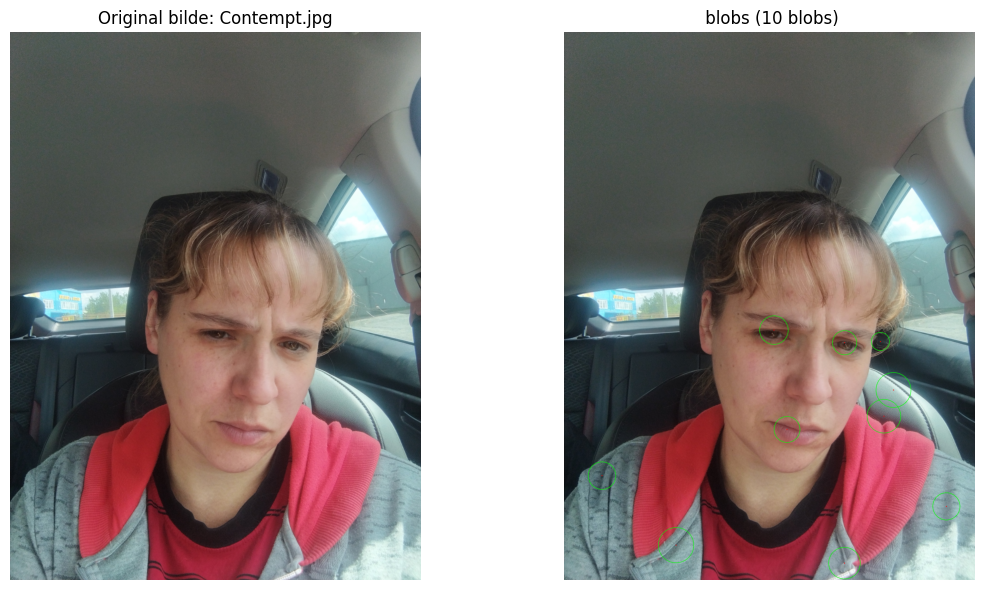


[Bilde 3/8] Prosesserer: Disgust.jpg
blobs detektert: 9
    - Blob på (761, 2930), radius: 105px
    - Blob på (1739, 2103), radius: 114px
    - Blob på (1194, 1574), radius: 88px
    - Blob på (1560, 1456), radius: 86px
    - Blob på (1724, 2845), radius: 112px
    - Blob på (300, 2871), radius: 186px
    - Blob på (504, 2972), radius: 78px
    - Blob på (1660, 1293), radius: 90px
    - Blob på (1496, 2960), radius: 137px


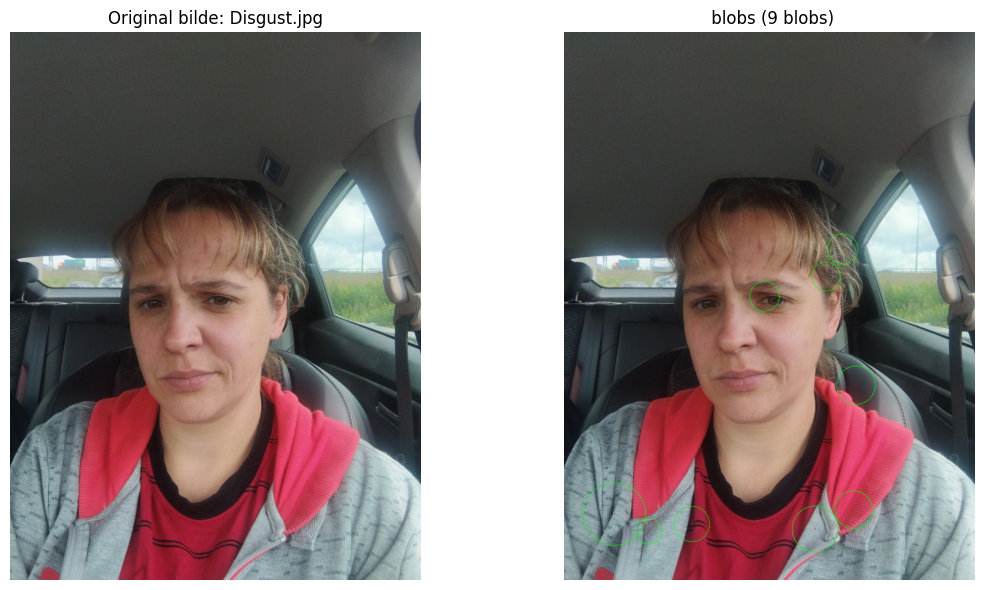


[Bilde 4/8] Prosesserer: Fear.jpg
blobs detektert: 10
    - Blob på (1441, 1633), radius: 91px
    - Blob på (890, 1623), radius: 119px
    - Blob på (1677, 2711), radius: 117px
    - Blob på (1072, 2323), radius: 90px
    - Blob på (1445, 1466), radius: 80px
    - Blob på (1572, 2687), radius: 103px
    - Blob på (1740, 1346), radius: 70px
    - Blob på (2209, 3065), radius: 58px
    - Blob på (1811, 2415), radius: 120px
    - Blob på (2010, 1801), radius: 75px


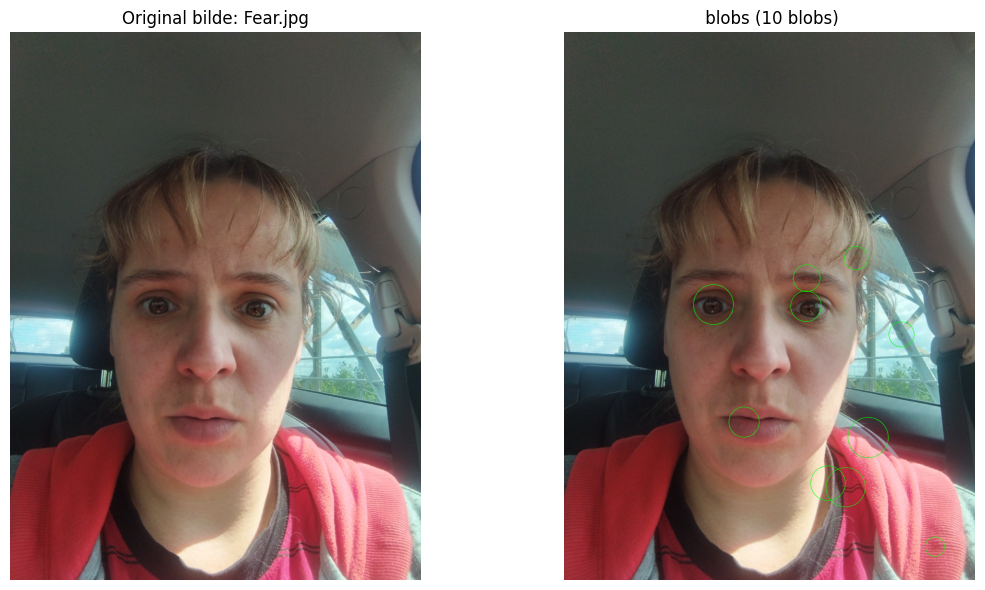


[Bilde 5/8] Prosesserer: Happy.jpg
blobs detektert: 7
    - Blob på (813, 1598), radius: 75px
    - Blob på (530, 1337), radius: 69px
    - Blob på (1337, 1637), radius: 68px
    - Blob på (1855, 2366), radius: 158px
    - Blob på (972, 2280), radius: 111px
    - Blob på (1339, 2075), radius: 95px
    - Blob på (2228, 1871), radius: 135px


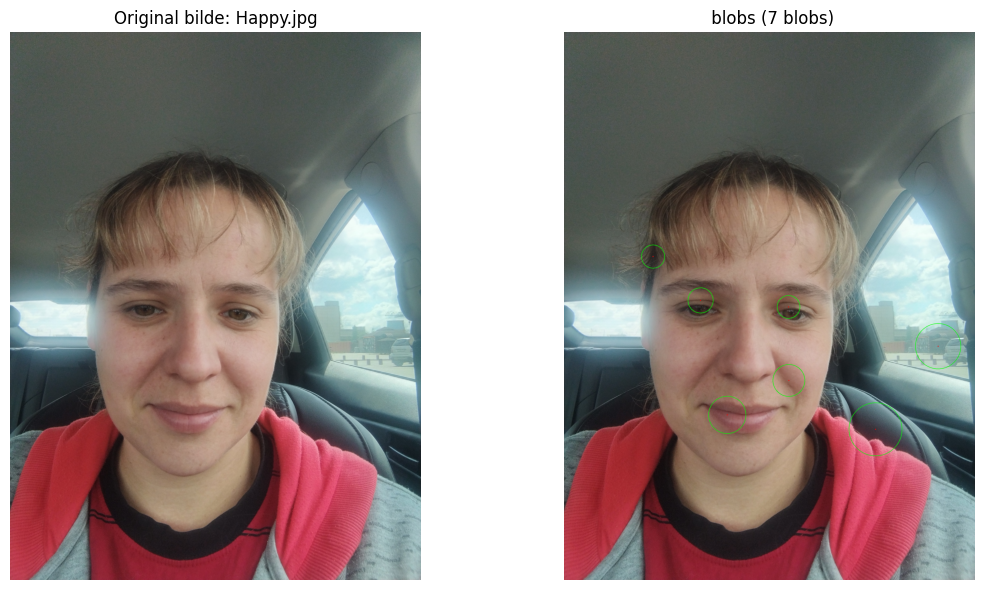


[Bilde 6/8] Prosesserer: Neutral.jpg
blobs detektert: 5
    - Blob på (303, 2869), radius: 107px
    - Blob på (1867, 2357), radius: 79px
    - Blob på (920, 1410), radius: 87px
    - Blob på (633, 1271), radius: 103px
    - Blob på (954, 1736), radius: 54px


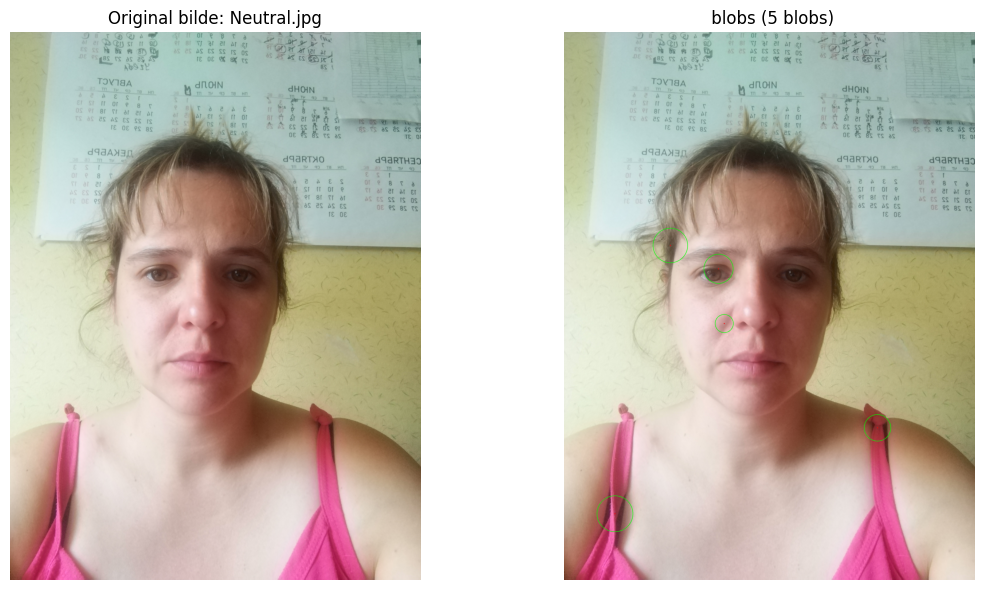


[Bilde 7/8] Prosesserer: Sad.jpg
blobs detektert: 6
    - Blob på (795, 1519), radius: 130px
    - Blob på (1258, 1510), radius: 75px
    - Blob på (974, 1897), radius: 108px
    - Blob på (1787, 758), radius: 235px
    - Blob på (1571, 1953), radius: 101px
    - Blob på (1253, 1882), radius: 88px


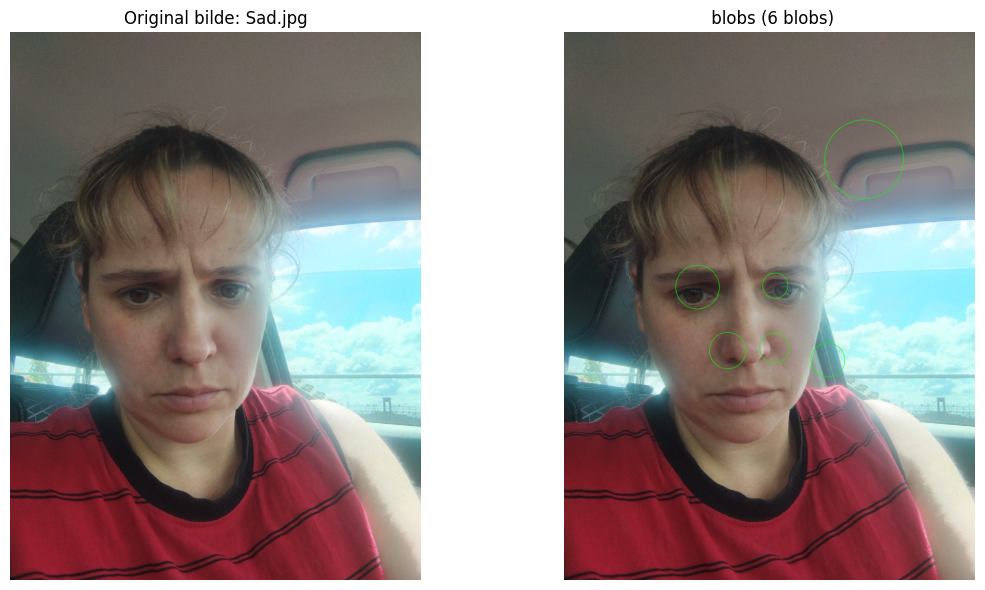


[Bilde 8/8] Prosesserer: Surprised.jpg
blobs detektert: 9
    - Blob på (1501, 734), radius: 59px
    - Blob på (976, 1544), radius: 75px
    - Blob på (949, 1309), radius: 118px
    - Blob på (1200, 2260), radius: 84px
    - Blob på (1523, 1548), radius: 86px
    - Blob på (1209, 1915), radius: 82px
    - Blob på (2133, 3062), radius: 64px
    - Blob på (1576, 1358), radius: 77px
    - Blob på (1586, 3179), radius: 72px


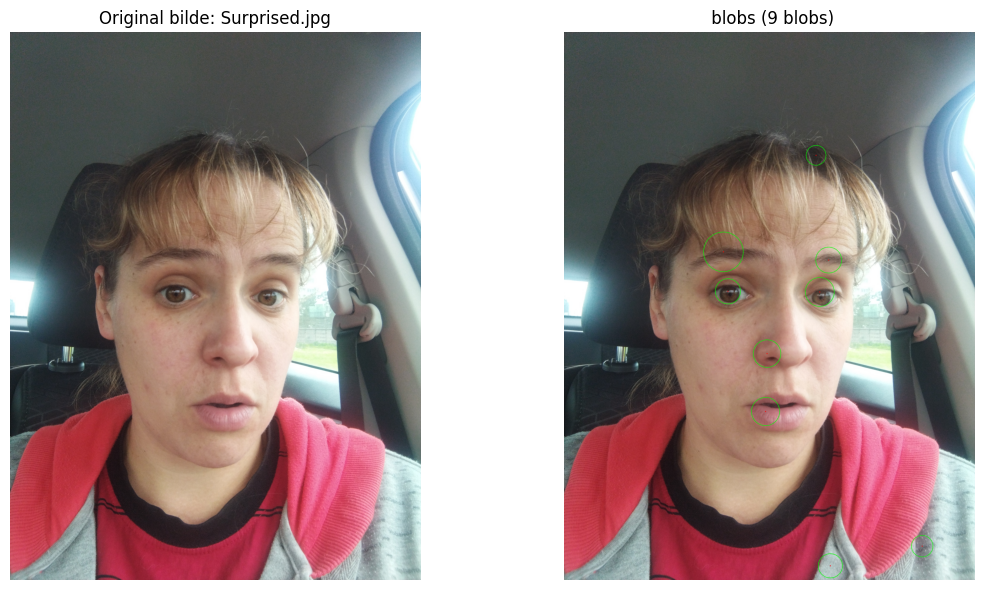


✓ Blob detection ferdig!


In [49]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Definer folderen
FOLDER = Path("bildeoppgave2/fjes/2/")
#FOLDER = Path("bildeoppgave2/carsblob/hatchback/")  


# Sett opp blob detector
params = cv2.SimpleBlobDetector_Params()

# Filter etter område
params.filterByArea = True
params.minArea = 5000
params.maxArea = 50000

# Filter etter konveksitet
params.filterByConvexity = True
params.minConvexity = 0.1

# Filter etter inertia
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Lag detektoren
detector = cv2.SimpleBlobDetector_create(params)

# Hent alle bildene fra folderen
image_files = sorted(FOLDER.glob("*.jpg")) + sorted(FOLDER.glob("*.png"))

print(f"Fant {len(image_files)} bilder i {FOLDER}")
print("-" * 60)

# Prosesser hver bildefil
for idx, img_path in enumerate(image_files, 1):
    print(f"\n[Bilde {idx}/{len(image_files)}] Prosesserer: {img_path.name}")
    
    # Les bildet
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"  ⚠️ Kunne ikke lese bildet")
        continue
    
    # Konverter til gråtoner for blob detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detekter blobs
    keypoints = detector.detect(gray)
    
    print(f"blobs detektert: {len(keypoints)}")
    
    # Tegn blobs på originalbildet
    img_with_blobs = img.copy()
    
    for kp in keypoints:
        # Tegn sirkel rundt hver blob
        x, y = int(kp.pt[0]), int(kp.pt[1])
        radius = int(kp.size / 2)
        cv2.circle(img_with_blobs, (x, y), radius, (0, 255, 0), 2)
        cv2.circle(img_with_blobs, (x, y), 3, (0, 0, 255), -1)  # Senter
        
        print(f"    - Blob på ({x}, {y}), radius: {radius}px")
    
    # Vis bildet med blobs
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original bilde: {img_path.name}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_with_blobs, cv2.COLOR_BGR2RGB))
    plt.title(f" blobs ({len(keypoints)} blobs)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("✓ Blob detection ferdig!")
print("=" * 60)

Fant 8 bilder i bildeoppgave2\fjes\2
------------------------------------------------------------

[Bilde 1/8] Prosesserer: Anger.jpg
  ✓ Antall konturer totalt: 1493
  ✓ Antall konturer etter filter (area ≥ 150): 47
    - Kontur #0: area=593.5px, perimeter=109.4px
    - Kontur #1: area=340.0px, perimeter=169.3px
    - Kontur #2: area=33093.0px, perimeter=1950.2px
    - Kontur #3: area=2411.5px, perimeter=509.6px
    - Kontur #4: area=3594.5px, perimeter=264.6px
    - Kontur #5: area=669.0px, perimeter=178.3px
    - Kontur #6: area=204.0px, perimeter=97.6px
    - Kontur #7: area=22616.0px, perimeter=1027.7px
    - Kontur #8: area=2235.5px, perimeter=784.3px
    - Kontur #9: area=158.5px, perimeter=63.7px
    - Kontur #10: area=641.5px, perimeter=135.6px
    - Kontur #11: area=656.5px, perimeter=120.2px
    - Kontur #12: area=398.0px, perimeter=211.2px
    - Kontur #13: area=495.0px, perimeter=358.4px
    - Kontur #14: area=167.5px, perimeter=113.2px
    - Kontur #15: area=176.5px, peri

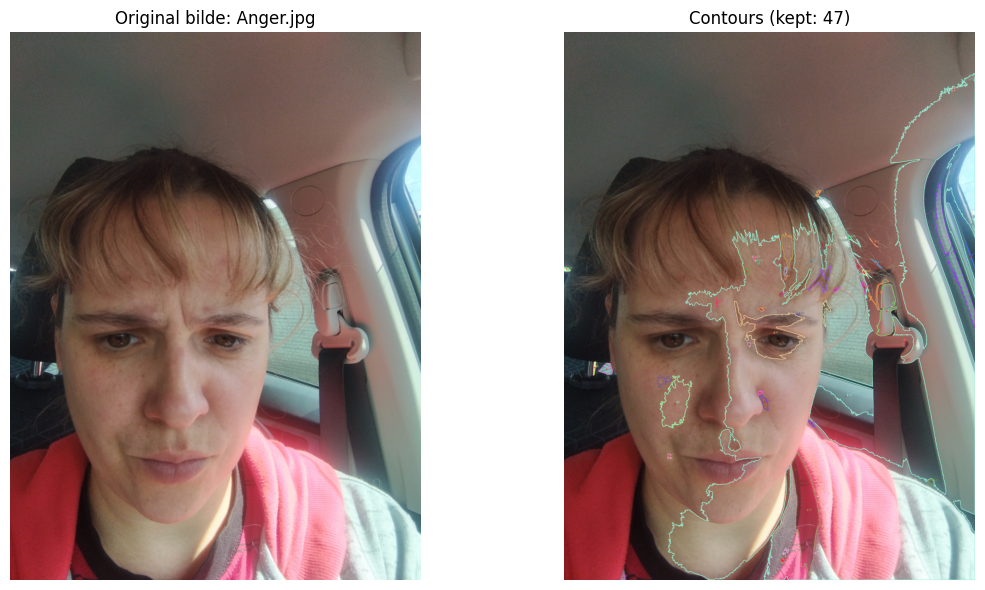


[Bilde 2/8] Prosesserer: Contempt.jpg
  ✓ Antall konturer totalt: 2302
  ✓ Antall konturer etter filter (area ≥ 150): 81
    - Kontur #0: area=398.0px, perimeter=195.7px
    - Kontur #1: area=185.5px, perimeter=106.0px
    - Kontur #2: area=150.5px, perimeter=85.8px
    - Kontur #3: area=179.0px, perimeter=89.3px
    - Kontur #4: area=46619.0px, perimeter=1993.0px
    - Kontur #5: area=294.0px, perimeter=103.7px
    - Kontur #6: area=153.0px, perimeter=74.4px
    - Kontur #7: area=243.0px, perimeter=71.6px
    - Kontur #8: area=286.0px, perimeter=82.4px
    - Kontur #9: area=192.0px, perimeter=121.4px
    - Kontur #10: area=155.5px, perimeter=124.5px
    - Kontur #11: area=180.5px, perimeter=111.5px
    - Kontur #12: area=108923.5px, perimeter=2063.6px
    - Kontur #13: area=291.0px, perimeter=156.0px
    - Kontur #14: area=470.0px, perimeter=187.1px
    - Kontur #15: area=2242.0px, perimeter=685.5px
    - Kontur #16: area=3681.5px, perimeter=645.9px
    - Kontur #17: area=590.0px, pe

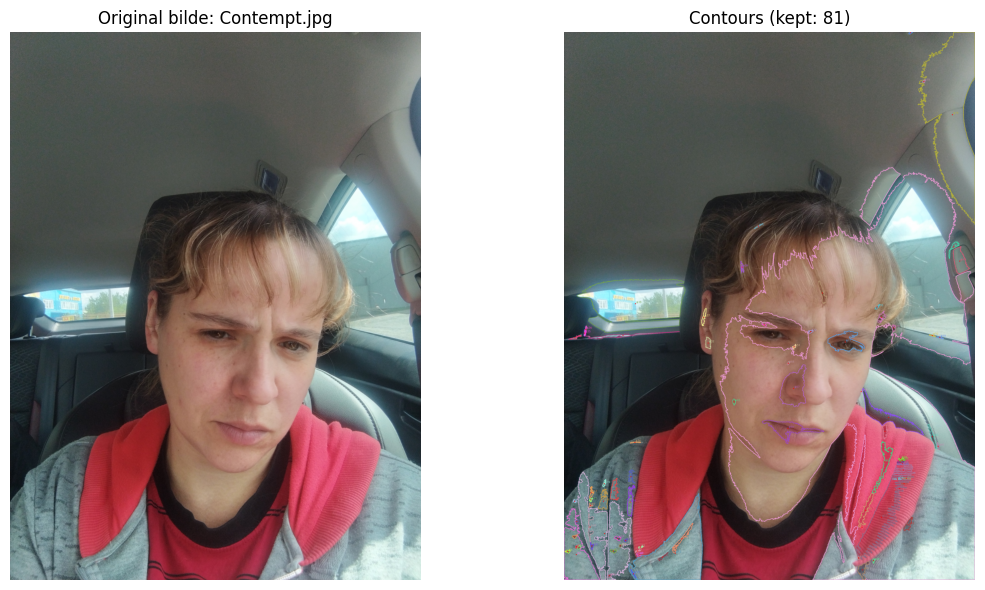


[Bilde 3/8] Prosesserer: Disgust.jpg
  ✓ Antall konturer totalt: 2204
  ✓ Antall konturer etter filter (area ≥ 150): 108
    - Kontur #0: area=968.0px, perimeter=272.8px
    - Kontur #1: area=1503.0px, perimeter=483.4px
    - Kontur #2: area=272.0px, perimeter=145.9px
    - Kontur #3: area=231.0px, perimeter=119.7px
    - Kontur #4: area=204.0px, perimeter=102.9px
    - Kontur #5: area=248.0px, perimeter=132.2px
    - Kontur #6: area=235.0px, perimeter=179.3px
    - Kontur #7: area=481688.5px, perimeter=11695.7px
    - Kontur #8: area=274.5px, perimeter=81.0px
    - Kontur #9: area=6046.5px, perimeter=591.7px
    - Kontur #10: area=287.0px, perimeter=107.7px
    - Kontur #11: area=449.0px, perimeter=121.7px
    - Kontur #12: area=353.5px, perimeter=104.7px
    - Kontur #13: area=151.0px, perimeter=74.8px
    - Kontur #14: area=2309.0px, perimeter=609.5px
    - Kontur #15: area=596.0px, perimeter=164.0px
    - Kontur #16: area=250.5px, perimeter=94.7px
    - Kontur #17: area=164.5px, p

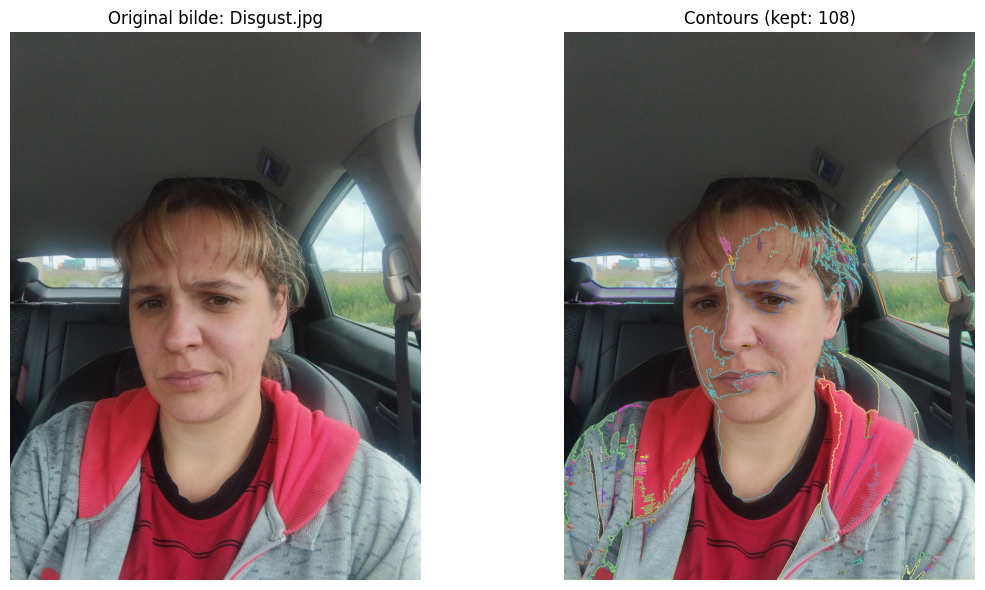


[Bilde 4/8] Prosesserer: Fear.jpg
  ✓ Antall konturer totalt: 1339
  ✓ Antall konturer etter filter (area ≥ 150): 59
    - Kontur #0: area=915.5px, perimeter=183.3px
    - Kontur #1: area=1968.5px, perimeter=236.6px
    - Kontur #2: area=11414.0px, perimeter=717.3px
    - Kontur #3: area=7769.5px, perimeter=685.7px
    - Kontur #4: area=397.0px, perimeter=235.6px
    - Kontur #5: area=409.5px, perimeter=180.0px
    - Kontur #6: area=561.0px, perimeter=206.9px
    - Kontur #7: area=1528.0px, perimeter=244.1px
    - Kontur #8: area=597.0px, perimeter=213.1px
    - Kontur #9: area=437.5px, perimeter=144.2px
    - Kontur #10: area=184.5px, perimeter=69.7px
    - Kontur #11: area=107651.5px, perimeter=2292.8px
    - Kontur #12: area=566.5px, perimeter=278.7px
    - Kontur #13: area=4944.5px, perimeter=451.4px
    - Kontur #14: area=358.0px, perimeter=174.5px
    - Kontur #15: area=646.5px, perimeter=222.6px
    - Kontur #16: area=167.0px, perimeter=91.7px
    - Kontur #17: area=240.5px, pe

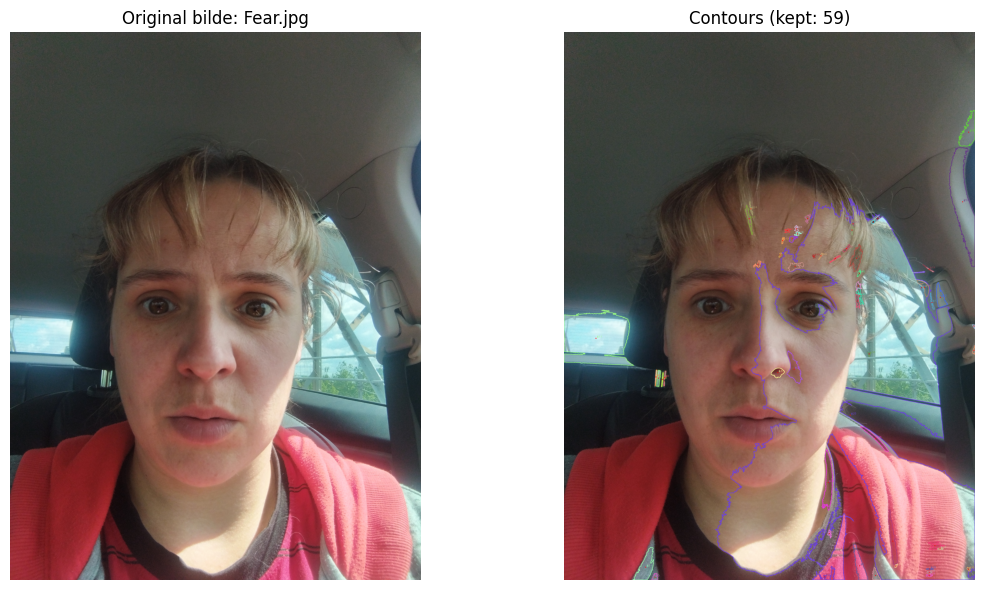


[Bilde 5/8] Prosesserer: Happy.jpg
  ✓ Antall konturer totalt: 2356
  ✓ Antall konturer etter filter (area ≥ 150): 57
    - Kontur #0: area=1469.0px, perimeter=289.3px
    - Kontur #1: area=5430.5px, perimeter=907.3px
    - Kontur #2: area=6912.0px, perimeter=458.9px
    - Kontur #3: area=938.5px, perimeter=275.3px
    - Kontur #4: area=580.0px, perimeter=157.7px
    - Kontur #5: area=599.5px, perimeter=135.8px
    - Kontur #6: area=800.0px, perimeter=235.4px
    - Kontur #7: area=252.5px, perimeter=135.3px
    - Kontur #8: area=26855.0px, perimeter=1209.1px
    - Kontur #9: area=11610.5px, perimeter=929.9px
    - Kontur #10: area=29937.0px, perimeter=1846.2px
    - Kontur #11: area=226.0px, perimeter=122.6px
    - Kontur #12: area=478.0px, perimeter=218.0px
    - Kontur #13: area=562.5px, perimeter=390.7px
    - Kontur #14: area=183.5px, perimeter=100.7px
    - Kontur #15: area=713.5px, perimeter=432.7px
    - Kontur #16: area=240.0px, perimeter=102.6px
    - Kontur #17: area=252.5px

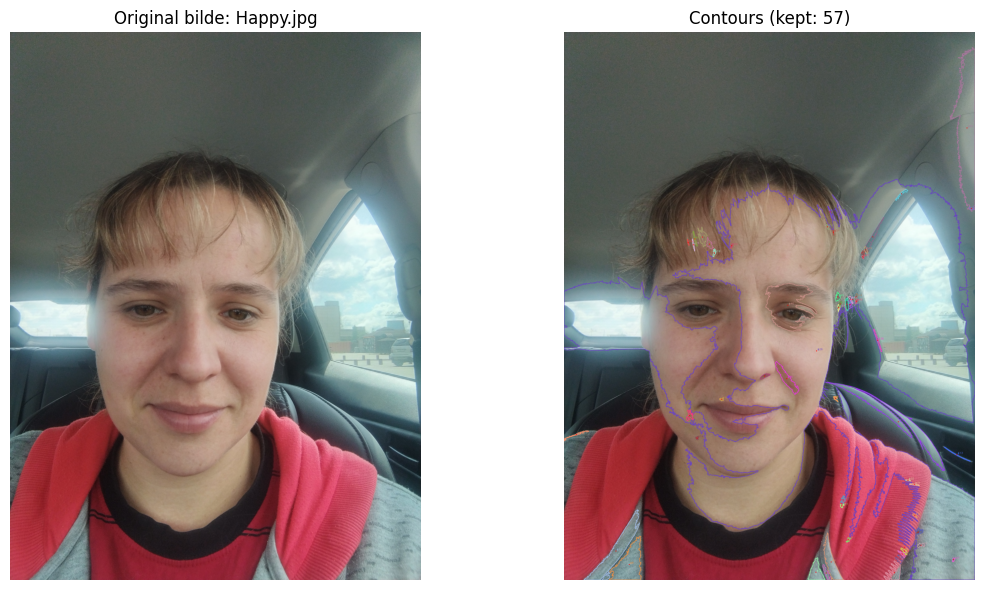


[Bilde 6/8] Prosesserer: Neutral.jpg
  ✓ Antall konturer totalt: 1594
  ✓ Antall konturer etter filter (area ≥ 150): 296
    - Kontur #0: area=1150.5px, perimeter=301.5px
    - Kontur #1: area=1099.0px, perimeter=376.1px
    - Kontur #2: area=209.0px, perimeter=104.6px
    - Kontur #3: area=12123.0px, perimeter=609.8px
    - Kontur #4: area=475.0px, perimeter=192.0px
    - Kontur #5: area=181.5px, perimeter=88.7px
    - Kontur #6: area=1616.5px, perimeter=393.3px
    - Kontur #7: area=5579.0px, perimeter=920.8px
    - Kontur #8: area=150.0px, perimeter=94.4px
    - Kontur #9: area=153.5px, perimeter=98.2px
    - Kontur #10: area=283920.5px, perimeter=2701.9px
    - Kontur #11: area=212.5px, perimeter=140.1px
    - Kontur #12: area=185.5px, perimeter=104.0px
    - Kontur #13: area=174.0px, perimeter=67.9px
    - Kontur #14: area=287.5px, perimeter=89.8px
    - Kontur #15: area=802777.5px, perimeter=8139.7px
    - Kontur #16: area=250.5px, perimeter=100.8px
    - Kontur #17: area=267.0p

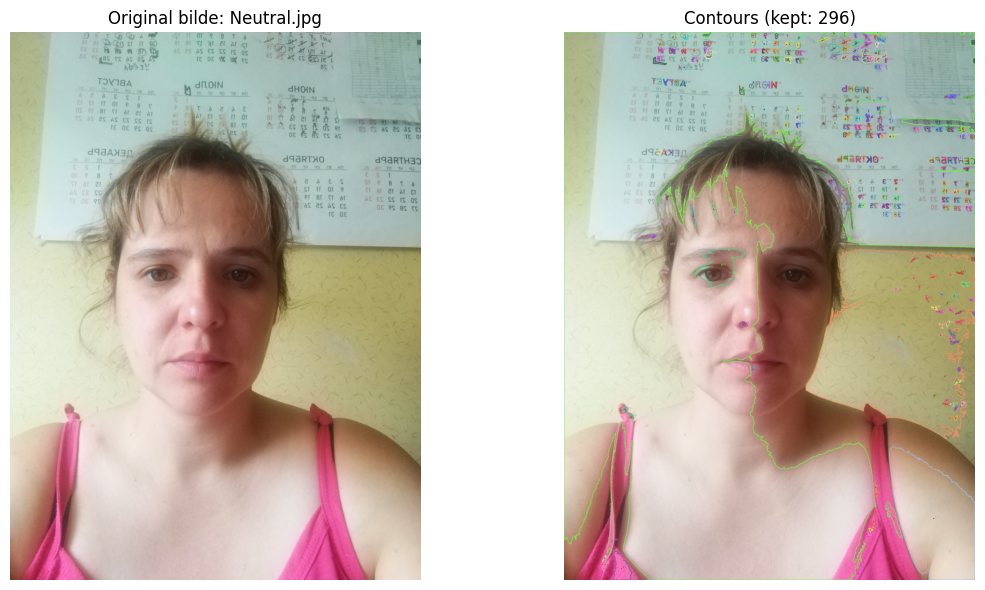


[Bilde 7/8] Prosesserer: Sad.jpg
  ✓ Antall konturer totalt: 991
  ✓ Antall konturer etter filter (area ≥ 150): 27
    - Kontur #0: area=309.5px, perimeter=80.2px
    - Kontur #1: area=50909.5px, perimeter=1794.5px
    - Kontur #2: area=205.5px, perimeter=100.7px
    - Kontur #3: area=82190.5px, perimeter=2413.6px
    - Kontur #4: area=737.5px, perimeter=231.6px
    - Kontur #5: area=315.5px, perimeter=174.3px
    - Kontur #6: area=1924035.5px, perimeter=17177.5px
    - Kontur #7: area=201.0px, perimeter=79.9px
    - Kontur #8: area=212.5px, perimeter=84.2px
    - Kontur #9: area=209.5px, perimeter=91.5px
    - Kontur #10: area=5059.5px, perimeter=781.5px
    - Kontur #11: area=14762.5px, perimeter=782.9px
    - Kontur #12: area=22154.5px, perimeter=1157.7px
    - Kontur #13: area=319.5px, perimeter=133.3px
    - Kontur #14: area=156.5px, perimeter=56.5px
    - Kontur #15: area=384.0px, perimeter=99.7px
    - Kontur #16: area=233.0px, perimeter=92.9px
    - Kontur #17: area=207.0px, p

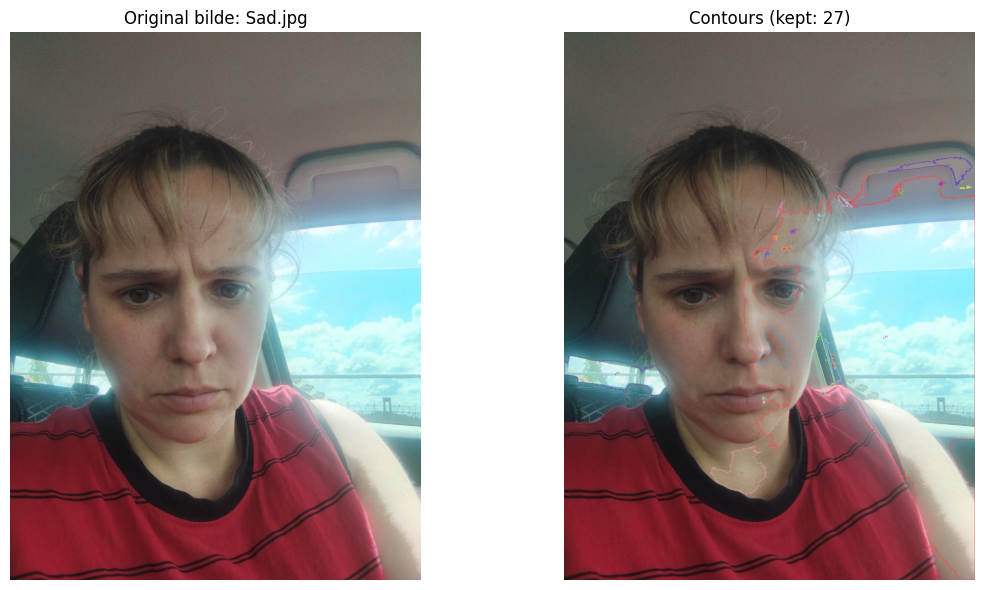


[Bilde 8/8] Prosesserer: Surprised.jpg
  ✓ Antall konturer totalt: 2493
  ✓ Antall konturer etter filter (area ≥ 150): 76
    - Kontur #0: area=155.0px, perimeter=98.1px
    - Kontur #1: area=28498.0px, perimeter=981.4px
    - Kontur #2: area=118116.5px, perimeter=2505.4px
    - Kontur #3: area=171.0px, perimeter=76.8px
    - Kontur #4: area=193.5px, perimeter=79.8px
    - Kontur #5: area=2554.5px, perimeter=632.9px
    - Kontur #6: area=326.5px, perimeter=130.5px
    - Kontur #7: area=183.5px, perimeter=118.8px
    - Kontur #8: area=391.0px, perimeter=341.2px
    - Kontur #9: area=226.0px, perimeter=59.5px
    - Kontur #10: area=574.0px, perimeter=191.7px
    - Kontur #11: area=575.5px, perimeter=186.9px
    - Kontur #12: area=2142.5px, perimeter=329.3px
    - Kontur #13: area=1115.5px, perimeter=253.7px
    - Kontur #14: area=210.0px, perimeter=151.2px
    - Kontur #15: area=11841.5px, perimeter=598.4px
    - Kontur #16: area=1731.5px, perimeter=202.8px
    - Kontur #17: area=421.5p

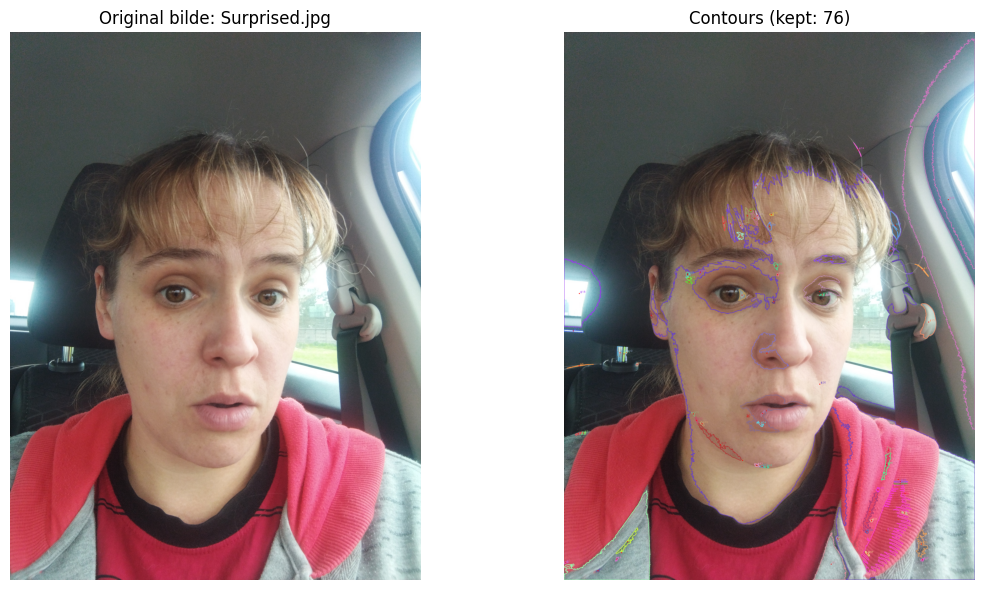


✓ Konturdeteksjon ferdig!


In [ ]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# -----------------------------
# Definer folderen (samme som hos deg)
# -----------------------------
FOLDER = Path("bildeoppgave2/fjes/2/")
# FOLDER = Path("bildeoppgave2/carsblob/hatchback/")

# Minste areal (px^2) for å beholde en kontur (støykontroll)
MIN_CONTOUR_AREA = 150.0

print(f"Fant {len(list(FOLDER.glob('*.jpg')))+len(list(FOLDER.glob('*.png')))} bilder i {FOLDER}")
print("-" * 60)

# -----------------------------
# Hent alle bildene
# -----------------------------
image_files = sorted(FOLDER.glob("*.jpg")) + sorted(FOLDER.glob("*.png"))
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# -----------------------------
# Prosesser hver bildefil
# -----------------------------
for idx, img_path in enumerate(image_files, 1):
    print(f"\n[Bilde {idx}/{len(image_files)}] Prosesserer: {img_path.name}")

    # Les bildet
    img = cv2.imread(str(img_path))
    if img is None:
        print("  ⚠️ Kunne ikke lese bildet")
        continue

    # --- Forbehandling for konturer ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu-terskel (global). For mørke objekter på lys bakgrunn kan du invertére.
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # binary = cv2.bitwise_not(binary)  # <- prøv denne hvis motivet er mørkt på lys bakgrunn

    # --- Finn konturer ---
    found = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Håndter forskjell mellom OpenCV 3/4 returverdier
    if len(found) == 3:
        _, contours, hierarchy = found
    else:
        contours, hierarchy = found

    print(f"  ✓ Antall konturer totalt: {len(contours)}")

    # Filtrer små konturer
    kept = [c for c in contours if cv2.contourArea(c) >= MIN_CONTOUR_AREA]
    print(f"  ✓ Antall konturer etter filter (area ≥ {MIN_CONTOUR_AREA:.0f}): {len(kept)}")

    # Kopi for tegning
    img_with_contours = img.copy()

    # Fargepalett (ulik farge per kontur)
    def color_for(i):
        # deterministisk "random"
        rng = np.random.default_rng(seed=i + 12345)
        return (int(rng.integers(50,255)),
                int(rng.integers(50,255)),
                int(rng.integers(50,255)))

    # Statistikk-buffer
    areas, perims = [], []

    # Tegn konturer og skriv ut stats
    for i, c in enumerate(kept):
        area = float(cv2.contourArea(c))
        perim = float(cv2.arcLength(c, True))
        areas.append(area)
        perims.append(perim)

        col = color_for(i)
        cv2.drawContours(img_with_contours, [c], -1, col, 2)

        # (valgfritt) merk senter + ID
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"]/M["m00"])
            cy = int(M["m01"]/M["m00"])
            cv2.circle(img_with_contours, (cx, cy), 3, (0,0,255), -1)
            cv2.putText(img_with_contours, f"#{i}", (cx+5, cy-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 1, cv2.LINE_AA)

        print(f"    - Kontur #{i}: area={area:.1f}px, perimeter={perim:.1f}px")

    # Sammendrag per bilde
    if areas:
        print("  — Statistikk (beholdte konturer):")
        print(f"      • Area:    min={min(areas):.1f}, max={max(areas):.1f}, mean={np.mean(areas):.1f}")
        print(f"      • Perim.:  min={min(perims):.1f}, max={max(perims):.1f}, mean={np.mean(perims):.1f}")
    else:
        print("  — Ingen konturer beholdt etter filter.")

    # --- Visualisering: original vs konturer ---
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original bilde: {img_path.name}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
    plt.title(f"Contours (kept: {len(kept)})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("✓ Konturdeteksjon ferdig!")
print("=" * 60)
